<a href="https://colab.research.google.com/github/akshaykumar2972/Netflix-Data-Analysis/blob/main/Netflix_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the libraries

In [186]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Importing the data from local file

In [187]:
df = pd.read_csv('/content/dataset.csv').drop_duplicates()
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [188]:
df.shape

(8807, 12)

In [189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [190]:
df['added_date'] = pd.to_datetime(df['date_added'], format='mixed').dt.date

In [191]:
df['duration'].unique()

array(['90 min', '2 Seasons', '1 Season', '91 min', '125 min',
       '9 Seasons', '104 min', '127 min', '4 Seasons', '67 min', '94 min',
       '5 Seasons', '161 min', '61 min', '166 min', '147 min', '103 min',
       '97 min', '106 min', '111 min', '3 Seasons', '110 min', '105 min',
       '96 min', '124 min', '116 min', '98 min', '23 min', '115 min',
       '122 min', '99 min', '88 min', '100 min', '6 Seasons', '102 min',
       '93 min', '95 min', '85 min', '83 min', '113 min', '13 min',
       '182 min', '48 min', '145 min', '87 min', '92 min', '80 min',
       '117 min', '128 min', '119 min', '143 min', '114 min', '118 min',
       '108 min', '63 min', '121 min', '142 min', '154 min', '120 min',
       '82 min', '109 min', '101 min', '86 min', '229 min', '76 min',
       '89 min', '156 min', '112 min', '107 min', '129 min', '135 min',
       '136 min', '165 min', '150 min', '133 min', '70 min', '84 min',
       '140 min', '78 min', '7 Seasons', '64 min', '59 min', '139 min',
    

In [192]:
df['running_time'] = (pd.to_numeric(df['duration'].str.split(' ').str[0], errors='coerce').fillna(0).astype(int))

In [193]:
df.drop(['date_added','duration', 'description'], axis=1, inplace=True)

In [194]:
df.describe()

,release_year,running_time
count,8807.000000,8807.000000
mean,2014.180198,69.823095
std,8.819312,50.822520
min,1925.000000,0.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2019.000000,106.000000
max,2021.000000,312.000000


In [195]:
df.describe(include='object')

,show_id,type,title,director,cast,country,rating,listed_in,added_date
count,8807,8807,8807,6173,7982,7976,8803,8807,8797
unique,8807,2,8807,4528,7692,748,17,514,1714
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,TV-MA,"Dramas, International Movies",2020-01-01
freq,1,6131,1,19,19,2818,3207,362,110


In [196]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
release_year,0
rating,4
listed_in,0
added_date,10


In [197]:
df.fillna({'director': 'Unknown', 'cast': 'Unknown', 'country': 'Unknown'}, inplace=True)

In [198]:
df.dropna(axis=0, inplace=True)

In [199]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
release_year,0
rating,0
listed_in,0
added_date,0


In [200]:
df.shape

(8793, 11)

In [201]:
df[df['director'] != 'Unknown']['director'].value_counts().reset_index().head(10)

,director,count
0,Rajiv Chilaka,19
1,"Raúl Campos, Jan Suter",18
2,Marcus Raboy,16
3,Suhas Kadav,16
4,Jay Karas,14
5,Cathy Garcia-Molina,13
6,Martin Scorsese,12
7,Jay Chapman,12
8,Youssef Chahine,12
9,Steven Spielberg,11


**Most popular Movie stars**

In [202]:
cast_series = df[df['type'] == 'Movie']['cast'].str.split(',').explode().str.strip()
cast_series = cast_series[~cast_series.isin(['Unknown', ''])]
cast_series.value_counts().head(10).sort_values(ascending=False).reset_index().rename(columns={'cast': 'Actor', 'count': 'Count_of_Movies'})

,Actor,Count_of_Movies
0,Anupam Kher,42
1,Shah Rukh Khan,35
2,Naseeruddin Shah,32
3,Akshay Kumar,30
4,Om Puri,30
5,Paresh Rawal,28
6,Amitabh Bachchan,28
7,Julie Tejwani,28
8,Rupa Bhimani,27
9,Boman Irani,27


**Most popular TV stars**

In [203]:
cast_series = df[df['type'] == 'TV Show']['cast'].str.split(',').explode().str.strip()
cast_series = cast_series[~cast_series.isin(['Unknown', ''])]
cast_series.value_counts().head(10).sort_values(ascending=False).reset_index().rename(columns={'cast': 'Actor', 'count': 'Count_Of_TV_Shows'})

,Actor,Count_Of_TV_Shows
0,Takahiro Sakurai,25
1,Yuki Kaji,19
2,Junichi Suwabe,17
3,Daisuke Ono,17
4,Yuichi Nakamura,16
5,Ai Kayano,16
6,Jun Fukuyama,15
7,Yoshimasa Hosoya,15
8,David Attenborough,14
9,Kana Hanazawa,13


**Countries producing more number of shows**

In [204]:
df[df['country'] != 'Unknown']['country'].value_counts().reset_index().head(10)

,country,count
0,United States,2812
1,India,972
2,United Kingdom,418
3,Japan,243
4,South Korea,199
5,Canada,181
6,Spain,145
7,France,124
8,Mexico,110
9,Egypt,106


In [205]:
df['rating'].value_counts().reset_index()

,rating,count
0,TV-MA,3205
1,TV-14,2157
2,TV-PG,861
3,R,799
4,PG-13,490
5,TV-Y7,333
6,TV-Y,306
7,PG,287
8,TV-G,220
9,NR,79


In [206]:
df[df['rating'].isin(['74 min', '84 min', '66 min'])]

,show_id,type,title,director,cast,country,release_year,rating,listed_in,added_date,running_time
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017,74 min,Movies,2017-04-04,0
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2010,84 min,Movies,2016-09-16,0
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2015,66 min,Movies,2016-08-15,0


In [207]:
df.drop(df[df['rating'].isin(['74 min', '84 min', '66 min'])].index, inplace=True)

In [208]:
df['rating'].value_counts().reset_index()

,rating,count
0,TV-MA,3205
1,TV-14,2157
2,TV-PG,861
3,R,799
4,PG-13,490
5,TV-Y7,333
6,TV-Y,306
7,PG,287
8,TV-G,220
9,NR,79


Text(0.5, 1.0, 'Distribution of TV Show Seasons')

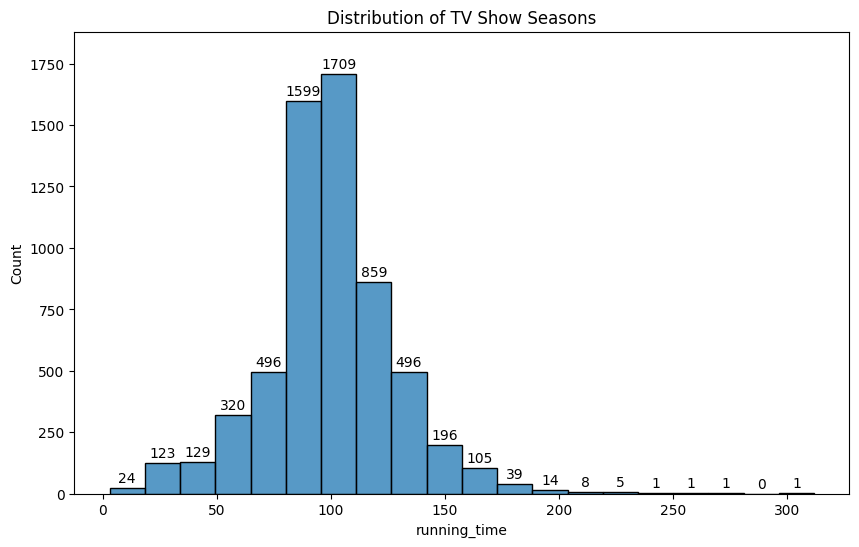

In [209]:
plt.figure(figsize=(10, 6))
ax_m = sns.histplot(x='running_time', data=df[df['type']=='Movie'], bins=20)
for container in ax_m.containers:
    ax_m.bar_label(container, padding=2)

plt.margins(y=0.1)

plt.title('Distribution of TV Show Seasons')

Text(0.5, 1.0, 'Distribution of TV Show Seasons')

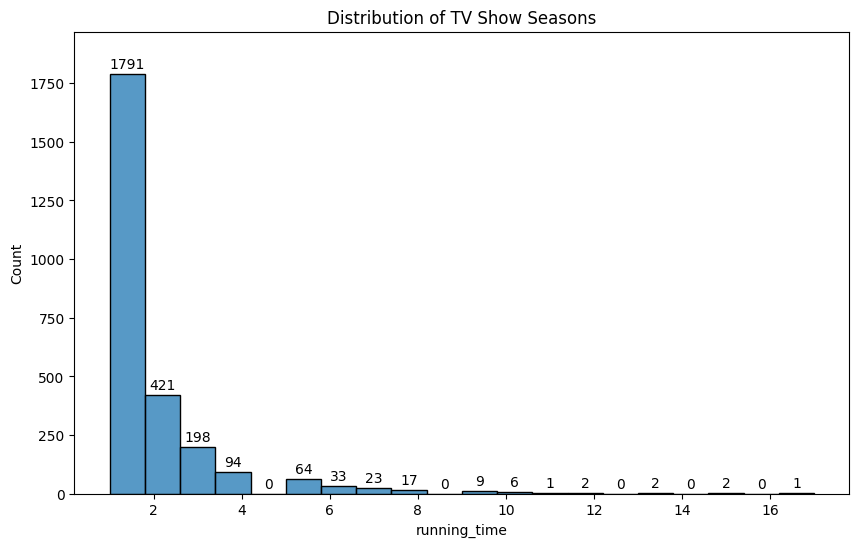

In [210]:
plt.figure(figsize=(10, 6))
ax = sns.histplot(x='running_time', data=df[df['type']=='TV Show'], bins=20)
for container in ax.containers:
    ax.bar_label(container, padding=2)

plt.margins(y=0.1)

plt.title('Distribution of TV Show Seasons')

In [211]:
df['added_date'] = pd.to_datetime(df['added_date'])
df['year_month'] = df['added_date'].dt.to_period('M')

In [212]:
all_counts = df.groupby(['year_month','type'])['show_id'].count().reset_index(name='count')
all_counts['year_month'] = all_counts['year_month'].dt.to_timestamp()

Text(0.5, 1.0, 'Total Movies and TV Shows Added Over Time')

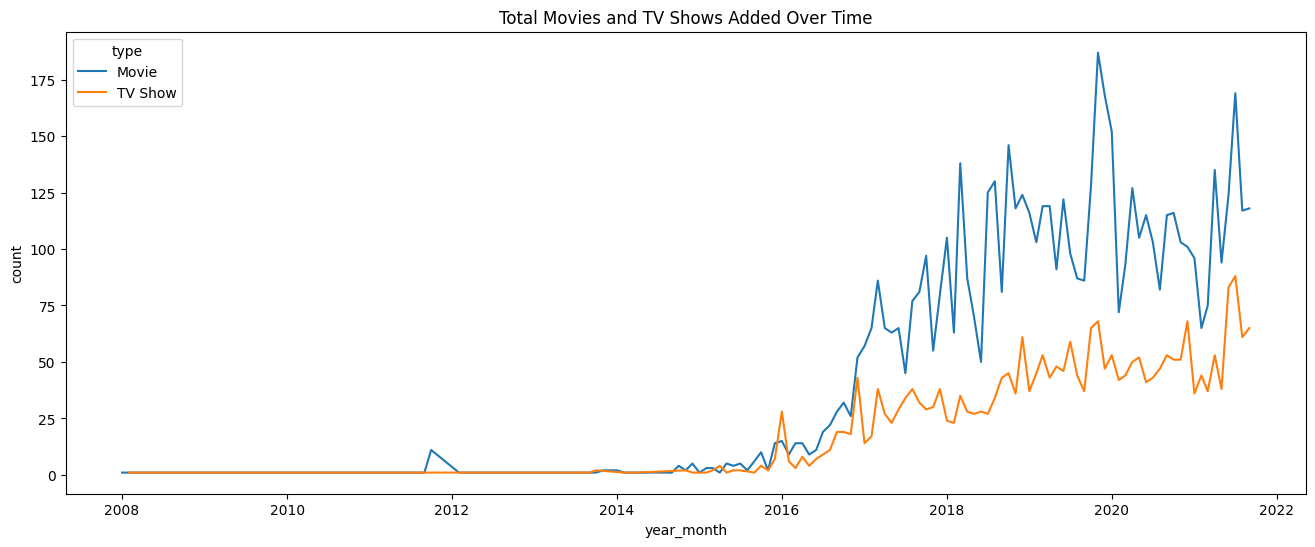

In [213]:
plt.figure(figsize=(16, 6))
sns.lineplot(x='year_month', y='count', data=all_counts, hue='type')
plt.title('Total Movies and TV Shows Added Over Time')

In [214]:
counts = df.groupby(['year_month', 'type']).size().reset_index(name='count')
counts = counts.sort_values('year_month')
counts['cumulative_count'] = counts.groupby('type')['count'].cumsum()
counts['year_month'] = counts['year_month'].dt.to_timestamp()

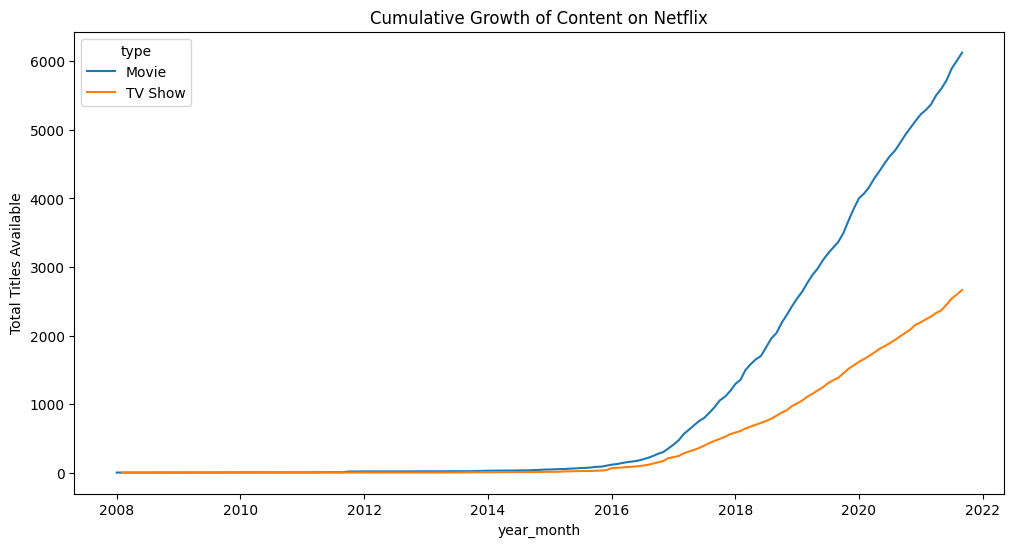

In [215]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=counts, x='year_month', y='cumulative_count', hue='type')
plt.title('Cumulative Growth of Content on Netflix')
plt.ylabel('Total Titles Available')
plt.show()

In [216]:
df.groupby(['country','type'])['show_id'].count().reset_index(name='count').sort_values('country')

,country,type,count
0,", France, Algeria",Movie,1
1,", South Korea",TV Show,1
2,Argentina,Movie,38
3,Argentina,TV Show,18
4,"Argentina, Brazil, France, Poland, Germany, De...",Movie,1
...,...,...,...
844,Venezuela,Movie,1
845,"Venezuela, Colombia",Movie,1
846,Vietnam,Movie,7
847,West Germany,Movie,1


In [217]:
country_series = df['country'].str.split(',').explode().str.strip()
country_series = country_series[~country_series.isin(['Unknown', ''])]
country_series.value_counts().reset_index().head(20)

,country,count
0,United States,3681
1,India,1046
2,United Kingdom,805
3,Canada,445
4,France,393
5,Japan,316
6,Spain,232
7,South Korea,231
8,Germany,226
9,Mexico,169


In [218]:
# Creating a temporary exploded dataframe
df_exploded = df.assign(country=df['country'].str.split(',')).explode('country')

In [219]:
# Cleaning up leading/trailing spaces and remove empty values
df_exploded['country'] = df_exploded['country'].str.strip()
df_exploded = df_exploded[~df_exploded['country'].isin(['', 'Unknown'])]

In [220]:
# Performing the groupby aggregation
final_output = (df_exploded.groupby(['country', 'type'])['show_id'].count().reset_index(name='count'))

In [221]:
wide_df = final_output.pivot(index='country', columns='type', values='count').fillna(0).reset_index()
wide_df = wide_df.rename(columns={'Movie': 'Movies', 'TV Show': 'TVShows'})
wide_df = wide_df.astype({'Movies':int,'TVShows':int})

In [222]:
#fetching top 20 countries with most number of Movies/Shows produced
df_exploded.groupby(['country'])['show_id'].count().reset_index(name='count').sort_values('count', ascending=False).head(20)['country']

,country
115,United States
45,India
114,United Kingdom
20,Canada
36,France
53,Japan
102,Spain
100,South Korea
38,Germany
67,Mexico


In [223]:
wide_df = wide_df[wide_df['country'].isin(df_exploded.groupby(['country'])['show_id'].count().reset_index(name='count').sort_values('count', ascending=False).head(20)['country'])]

In [224]:
wide_df

type,country,Movies,TVShows
4,Argentina,71,20
6,Australia,94,64
15,Brazil,66,31
20,Canada,319,126
23,China,114,48
33,Egypt,102,15
36,France,303,90
38,Germany,182,44
42,Hong Kong,100,5
45,India,962,84


In [225]:
total_content = wide_df['Movies'] + wide_df['TVShows']
wide_df['Movies'] = (wide_df['Movies'] / total_content * 100).round(2)
wide_df['TVShows'] = (wide_df['TVShows'] / total_content * 100).round(2)

In [226]:
wide_df.index.name = None
wide_df = wide_df.reset_index(drop=True)
wide_df['Movies'] = wide_df['Movies'].apply(lambda x: f"{x:.2f}%")
wide_df['TVShows'] = wide_df['TVShows'].apply(lambda x: f"{x:.2f}%")

In [227]:
print(wide_df)

type         country  Movies TVShows
0          Argentina  78.02%  21.98%
1          Australia  59.49%  40.51%
2             Brazil  68.04%  31.96%
3             Canada  71.69%  28.31%
4              China  70.37%  29.63%
5              Egypt  87.18%  12.82%
6             France  77.10%  22.90%
7            Germany  80.53%  19.47%
8          Hong Kong  95.24%   4.76%
9              India  91.97%   8.03%
10         Indonesia  95.56%   4.44%
11             Italy  74.75%  25.25%
12             Japan  37.66%  62.34%
13            Mexico  65.68%  34.32%
14           Nigeria  91.26%   8.74%
15       South Korea  26.41%  73.59%
16             Spain  73.71%  26.29%
17            Turkey  73.45%  26.55%
18    United Kingdom  66.34%  33.66%
19     United States  74.68%  25.32%


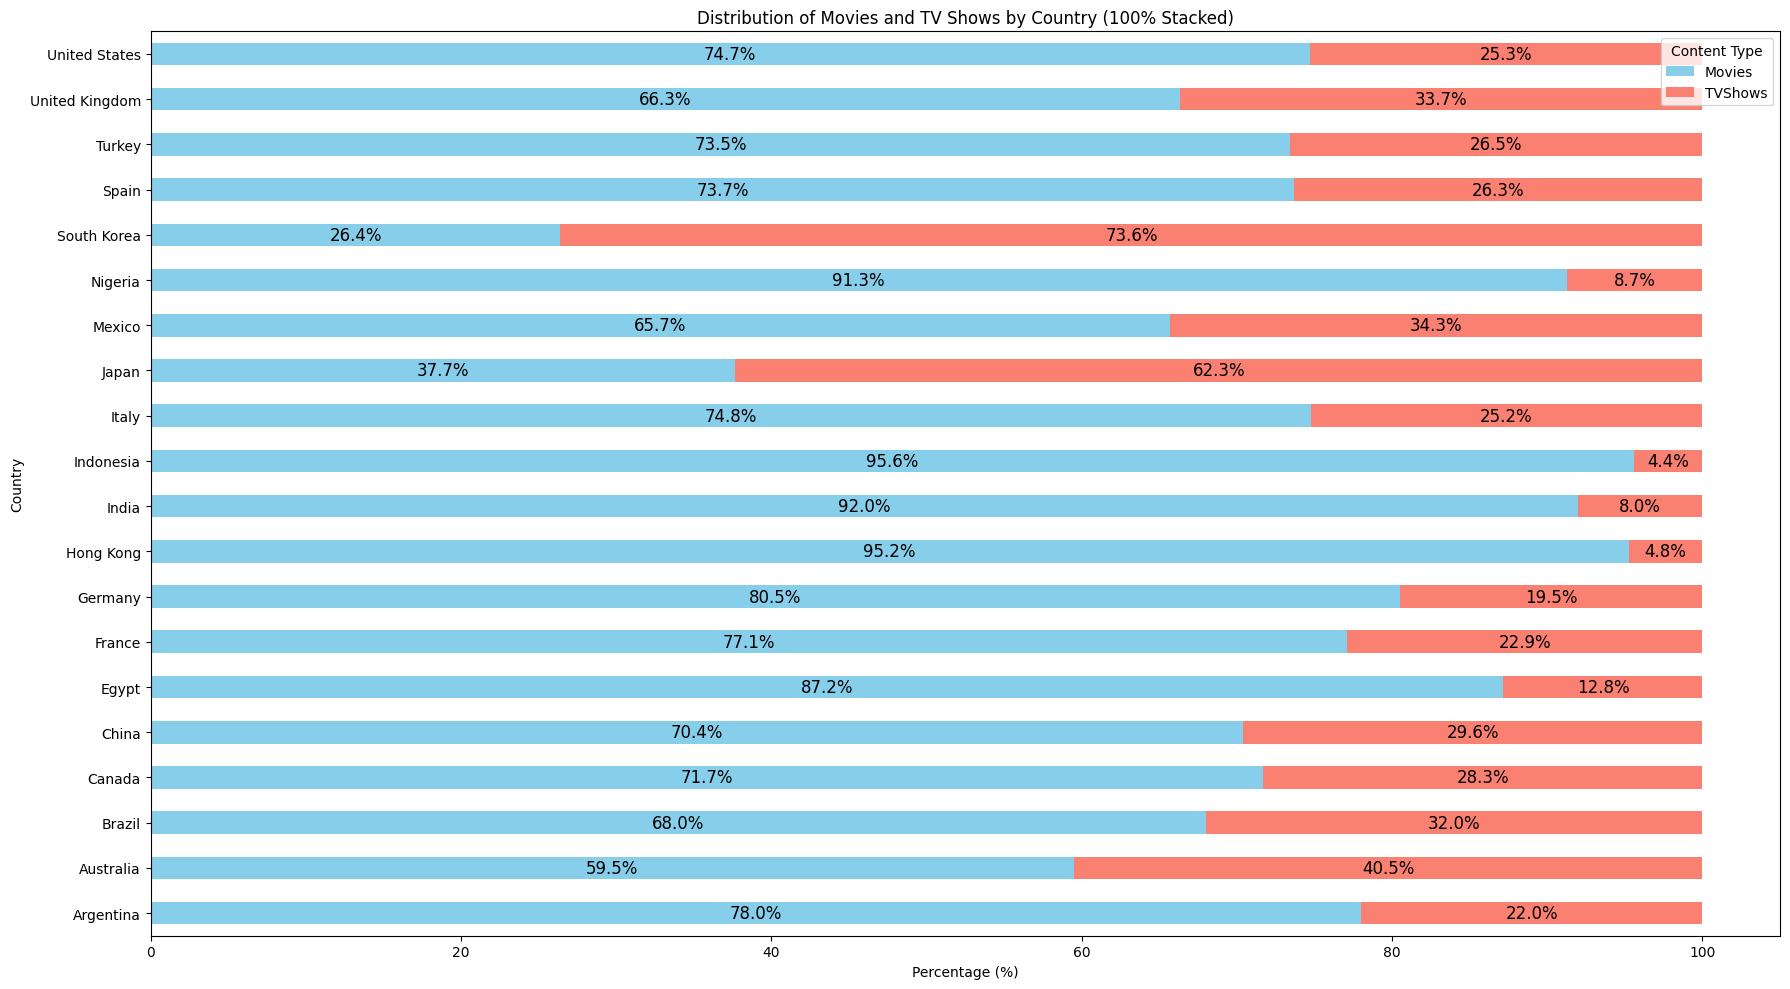

In [228]:
# Create a copy to avoid modifying the original wide_df if needed later
plot_df = wide_df.copy()

# Convert 'Movies' and 'TVShows' columns from percentage strings back to numeric
plot_df['Movies'] = plot_df['Movies'].str.replace('%', '').astype(float)
plot_df['TVShows'] = plot_df['TVShows'].str.replace('%', '').astype(float)

# Set country as index for plotting stacked bars
plot_df_indexed = plot_df.set_index('country')

# Create the 100% stacked horizontal bar chart
ax = plot_df_indexed[['Movies', 'TVShows']].plot(
    kind='barh',
    stacked=True,
    figsize=(18, 10),
    color=['skyblue', 'salmon'])

plt.title('Distribution of Movies and TV Shows by Country (100% Stacked)')
plt.xlabel('Percentage (%)')
plt.ylabel('Country')
plt.xticks(rotation=0)
plt.legend(title='Content Type')

# Add percentage labels to each bar segment
for container in ax.containers:
    labels = [f'{w:.1f}%' if (w := v.get_width()) > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=12)

plt.tight_layout()
plt.show()

In [229]:
# 1. Create a separate exploded dataframe for directors
director_df = df.assign(director=df['director'].str.split(',')).explode('director')

# 2. Clean up names and filter out unknowns
director_df['director'] = director_df['director'].str.strip()
director_df = director_df[~director_df['director'].isin(['', 'Unknown'])]

# 3. Group by Year and Director
# Using 'date_added.dt.year' to get the count specifically per year
director_yearly = (director_df.groupby([director_df['added_date'].dt.year, 'director'])['show_id'].count().reset_index(name='show_count'))

# 4. Rename the year column and sort
director_yearly.columns = ['year', 'director', 'show_count']
director_yearly = director_yearly.sort_values(['director','year'], ascending=[False, False])

print(director_yearly.head(20))

      year                    director  show_count
5978  2021                Şenol Sönmez           1
3751  2019                Şenol Sönmez           1
5977  2021            Ömer Faruk Sorak           2
2408  2018            Ömer Faruk Sorak           1
2407  2018         Óskar Thór Axelsson           1
3750  2019            Ísold Uggadóttir           1
5976  2021                  Éric Warin           1
5975  2021               Éric Toledano           1
5974  2021                  Éric Judor           1
2406  2018                 Çagan Irmak           1
5973  2021               Ángeles Reiné           1
4991  2020       Ángel Gómez Hernández           1
2405  2018             Álvaro Longoria           1
4990  2020  Álvaro Delgado-Aparicio L.           1
2404  2018             Álvaro Brechner           1
1271  2017          Álex de la Iglesia           1
403   2016          Álex de la Iglesia           1
4989  2020                 Àlex Pastor           1
3749  2019                 Àlex

In [230]:
director_career = director_yearly.groupby('director')['year'].agg(['min', 'max']).reset_index().sort_values('min', ascending=True).head(10)
director_career['years_active'] = director_career['max'] - director_career['min']
director_career[director_career['years_active'] > 0].sort_values('years_active', ascending=False)

,director,min,max,years_active
2094,Joe Dante,2009,2019,10


In [231]:
# 1. Create a separate exploded dataframe for cast
cast_df = df.assign(cast=df['cast'].str.split(',')).explode('cast')

# 2. Clean up names and filter out unknowns/empty strings
cast_df['cast'] = cast_df['cast'].str.strip()
cast_df = cast_df[~cast_df['cast'].isin(['', 'Unknown'])]

# 3. Group by Year and Actor to get the yearly counts
cast_yearly = (cast_df.groupby([cast_df['added_date'].dt.year, 'cast'])['show_id'].count().reset_index(name='show_count'))
cast_yearly.columns = ['year', 'cast', 'show_count']

# 4. Calculate career span (Min/Max year and years_active)
cast_career = (cast_yearly.groupby('cast')['year'].agg(['min', 'max']).reset_index())
cast_career['years_active'] = cast_career['max'] - cast_career['min']

# 5. Filter and Sort (Filtering FIRST to avoid the index warning)
# We look for actors with at least 1 year gap between their first and last project
top_cast_careers = (cast_career[cast_career['years_active'] > 0].sort_values('years_active', ascending=False).head(25))
print(top_cast_careers)

                       cast   min   max  years_active
33770             Tony Todd  2009  2021            12
24868      Nikolaj Lie Kaas  2009  2020            11
21485     Mario Van Peebles  2011  2021            10
21569           Mark Hamill  2011  2021            10
35146        William Devane  2011  2021            10
28065         Richard Masur  2011  2021            10
27670          Raúl Arévalo  2011  2021            10
27724         Rebecka Hemse  2009  2019            10
20368            Luis Tosar  2011  2021            10
20390            Lukas Haas  2011  2021            10
20514        Lynn Whitfield  2011  2021            10
28676           Ron Perlman  2011  2021            10
11068    Gael García Bernal  2011  2021            10
26474   Peter Michael Goetz  2011  2021            10
25007      Noble Willingham  2011  2021            10
15215        Jill Clayburgh  2011  2021            10
33112        Theodore Bikel  2011  2021            10
4581              Brad Pitt 

In [232]:
df['listed_in'] = df['listed_in'].str.split(',')
df_exploded = df.explode('listed_in')
df_exploded['listed_in'] = df_exploded['listed_in'].str.strip()
top_genre_by_count = df_exploded['listed_in'].value_counts().reset_index().head(25)

<Axes: xlabel='count', ylabel='listed_in'>

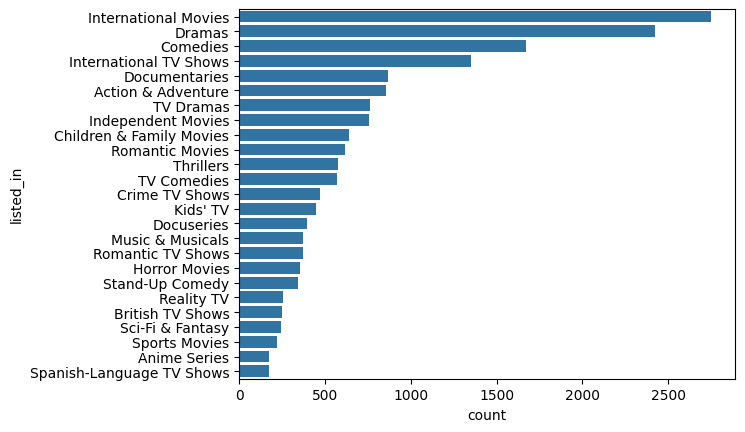

In [233]:
sns.barplot(x='count', y='listed_in', data=top_genre_by_count)

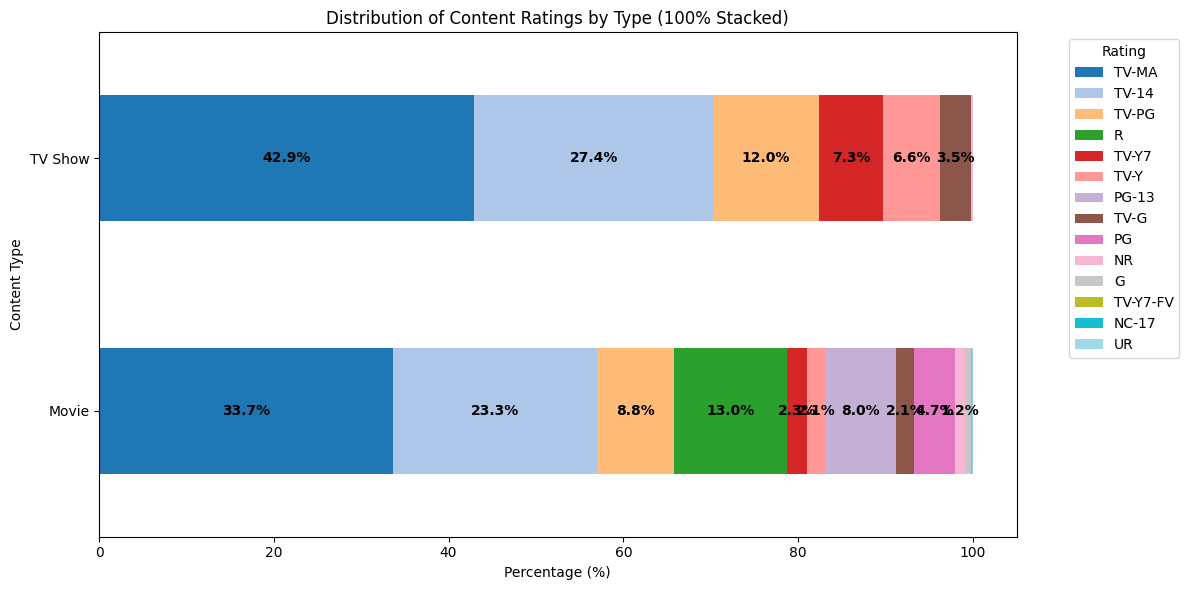

In [243]:
# Group by type and rating, then count the occurrences
rating_by_type = df.groupby(['type', 'rating']).size().unstack(fill_value=0)

# Calculate percentages for a 100% stacked bar chart
rating_by_type_percent = rating_by_type.apply(lambda x: x / x.sum() * 100, axis=1)

# Sort columns (ratings) by their mean contribution across Movie and TV Show types
sorted_columns = rating_by_type_percent.mean().sort_values(ascending=False).index
rating_by_type_percent = rating_by_type_percent[sorted_columns]

# Plotting the 100% stacked horizontal bar chart
ax = rating_by_type_percent.plot(kind='barh', stacked=True, figsize=(12,6), cmap='tab20')

plt.title('Distribution of Content Ratings by Type (100% Stacked)')
plt.xlabel('Percentage (%)')
plt.ylabel('Content Type')
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentage labels to each bar segment, making them bold and ignoring values less than 1%
for container in ax.containers:
    labels = [f'{w:.1f}%' if w >= 1 else '' for w in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()